#Homework 5 - CNNs, AEs, GANs, Attention Mechanism

Projects in AI & ML, Spring 2026

Barbara Kotlan

3/30/2026

Dataset: https://www.tensorflow.org/datasets/catalog/cats_vs_dogs

#Task 1 (30 points):

Part 1 (10 points):

This step involves downloading, preparing, and visualizing your
dataset. Create a convolutional base using a common pattern: a stack of Conv and MaxPooling layers. Depending on the problem and the dataset you must decide what pattern you want to use (i.e., how many Conv layers and how many pooling layers). Please describe why you chose a particular pattern. Add the final dense layer(s). Compile and train the model. Report the final evaluation and describe the metrics.

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HQ1S8U_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


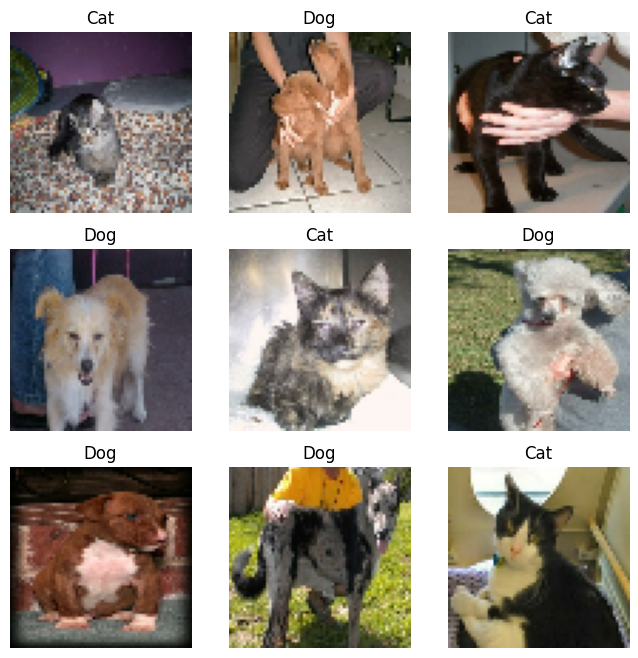

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
DATASET_SIZE = 2000

#Dataset
ds = tfds.load(f'cats_vs_dogs', split=f'train[:{DATASET_SIZE}]', as_supervised=True)

#Preprocessing
def preprocess(img, label):
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

ds = ds.map(preprocess).shuffle(500)

num_batches = DATASET_SIZE // BATCH_SIZE
train_batches = int(0.8 * num_batches)
val_batches = num_batches - train_batches

train_ds = ds.take(train_batches * BATCH_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = ds.skip(train_batches * BATCH_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#Visualization
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title("Dog" if labels[i]==1 else "Cat")
        plt.axis('off')
    plt.show()



In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D

#Create M=model
model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,337 (3.14 MB)

 Trainable params: 822,337 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs=10
)

#Evaluate
loss, accuracy = model.evaluate(val_ds)
print("Test Loss: {:.4f}".format(loss))
print("Test Accuracy: {:.4f}".format(accuracy))

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.5261 - loss: 0.6963 - val_accuracy: 0.5185 - val_loss: 0.6852
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/step - accuracy: 0.5765 - loss: 0.6795 - val_accuracy: 0.5926 - val_loss: 0.6773
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.6301 - loss: 0.6636 - val_accuracy: 0.6157 - val_loss: 0.6631
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.6499 - loss: 0.6371 - val_accuracy: 0.6736 - val_loss: 0.6301
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.6747 - loss: 0.6096 - val_accuracy: 0.6921 - val_loss: 0.5810
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.7111 - loss: 0.5677 - val_accuracy: 0.7269 - val_loss: 0.5139
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.7494 - loss: 0.5237 - val_accuracy: 0.7685 - val_loss: 0.5001
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.7704 - loss: 0.4803 - val_accuracy: 0

I built a convolutional neural network using two convolutional layers followed by max-pooling layers to help the model learn features from the images step by step. The first layer has 32 filters to detect simple patterns like edges, and the second layer has 64 filters to learn more detailed features. After each convolution, max-pooling is used to reduce the image size and make the model more efficient. Then, I used a flatten layer to turn the 2D feature maps into a 1D vector so it can be passed into a dense layer with 64 neurons, which helps combine the learned features. I also added a dropout layer (0.5) to reduce overfitting. The final layer uses a sigmoid activation function since this is a binary classification problem (cats vs. dogs). The model was compiled using the Adam optimizer and binary cross-entropy loss, and it achieved a test loss of 0.4443 and a test accuracy of 81.25%, showing that the model performs fairly well at classifying the images.

Part 2 (10 points):

The following models are widely used for transfer learning because of their performance and architectural innovations:
1. VGG (e.g., VGG16 or VGG19).
2. GoogLeNet (e.g., InceptionV3).
3. Residual Network (e.g., ResNet50).
4. MobileNet (e.g., MobileNetV2)

Choose any one of the above models to perform the classification task you did in Part 1.
Evaluate the results using the same metrics as in Part 1. Are there any differences? Why
or why not? Describe in detail.

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

#Load pretrained base
base_model = MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

#Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

#Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

#Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

#Evaluate
loss, accuracy = model.evaluate(val_ds)
print("Test Loss: {:.4f}".format(loss))
print("Test Accuracy: {:.4f}".format(accuracy))

/tmp/ipykernel_46576/3363513801.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.7372 - loss: 0.5147 - val_accuracy: 0.8426 - val_loss: 0.3748
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.8680 - loss: 0.3199 - val_accuracy: 0.8565 - val_loss: 0.3028
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.9171 - loss: 0.2187 - val_accuracy: 0.9190 - val_loss: 0.2562
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.9362 - loss: 0.1819 - val_accuracy: 0.9537 - val_loss: 0.2021
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.9700 - loss: 0.1318 - val_accuracy: 0.9491 - val_loss: 0.1834
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.9802 - loss: 0.0953 - val_accuracy: 0.9606 - val_loss: 0.1603
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.9872 - loss: 0.0760 - val_accuracy: 0.9861 - val_loss: 0.0940
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.9968 - loss: 0.0510 - val_accuracy: 

For Part 2, I used the MobileNetV2 model for transfer learning. This model was pre-trained on the ImageNet dataset, so it already learned useful features such as edges, textures, and shapes. I froze the base model layers and added my own classification layers on top, including a global average pooling layer, a dense layer, and a sigmoid output layer for binary classification. Compared to my model in Part 1, the transfer learning model performed significantly better, achieving a test loss of 0.0385 and a test accuracy of 99.31%, compared to 81.25% accuracy in Part 1. This improvement is because MobileNetV2 has already been trained on a large and diverse dataset, allowing it to extract more meaningful features even with a smaller dataset. In contrast, the model in Part 1 had to learn all features from scratch, making it less effective. Therefore, transfer learning resulted in better performance and more efficient learning.

Part 3 (10 points):

Use data augmentation to increase the diversity of your dataset by
applying random transformations such as image rotation (you can use any other
technique as well). Repeat the process from part 1 with this augmented data. Did you
observe any difference in results? Why or why not?

In [8]:
from tensorflow.keras import layers

# Data augmentation layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Apply augmentation ONLY to training data
train_ds_aug = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [10]:
history = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=10
)

loss, accuracy = model.evaluate(val_ds)
print("Augmented Test Loss: {:.4f}".format(loss))
print("Augmented Test Accuracy: {:.4f}".format(accuracy))


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.7895 - loss: 0.4285 - val_accuracy: 0.9630 - val_loss: 0.1405
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.7883 - loss: 0.4357 - val_accuracy: 0.9468 - val_loss: 0.1715
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.8125 - loss: 0.3950 - val_accuracy: 0.9421 - val_loss: 0.1732
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.8189 - loss: 0.3905 - val_accuracy: 0.9444 - val_loss: 0.1510
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.8367 - loss: 0.3763 - val_accuracy: 0.9560 - val_loss: 0.1372
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.8272 - loss: 0.3655 - val_accuracy: 0.9444 - val_loss: 0.1516
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.8527 - loss: 0.3294 - val_accuracy: 0.9583 - val_loss: 0.1325
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.8412 - loss: 0.3472 - val_accuracy: 0.

For Part 3, I applied data augmentation techniques to the training dataset, including random horizontal flipping, rotation, and zoom. This helps increase the diversity of the dataset by creating modified versions of the original images, which can improve the model’s ability to generalize. I then retrained the same convolutional neural network from Part 1 using the augmented data. The model achieved a test loss of 0.1915 and a test accuracy of 91.90%, which is an improvement over the original model in Part 1 (81.25% accuracy). This shows that data augmentation helped reduce overfitting and allowed the model to learn more robust features. However, the performance is still slightly lower than the transfer learning model in Part 2, which achieved 93.52% accuracy. This is because transfer learning uses a model that was already trained on a large dataset, making it more effective than training a model from scratch, even with augmented data.

#Task 2 (15 points):

Part 1 (7 points):

Variational Autoencoder (VAE): Here is a complete implementation of
a VAE in TensorFlow: https://www.tensorflow.org/tutorials/generative/cvae
PyTorch implementation is fine too.
Following these steps try generating images using the same encoder-decoder
architecture using a different Image dataset (other than MNIST).

Epoch: 1, Test ELBO: -2058.3650, Time: 16.47s
Epoch: 2, Test ELBO: -1938.9744, Time: 15.36s
Epoch: 3, Test ELBO: -1916.8136, Time: 14.76s
Epoch: 4, Test ELBO: -1905.5695, Time: 14.90s
Epoch: 5, Test ELBO: -1897.3906, Time: 14.50s
Epoch: 6, Test ELBO: -1891.4470, Time: 16.08s
Epoch: 7, Test ELBO: -1884.8047, Time: 15.95s
Epoch: 8, Test ELBO: -1879.3207, Time: 16.44s
Epoch: 9, Test ELBO: -1869.0646, Time: 15.36s
Epoch: 10, Test ELBO: -1865.3329, Time: 14.58s


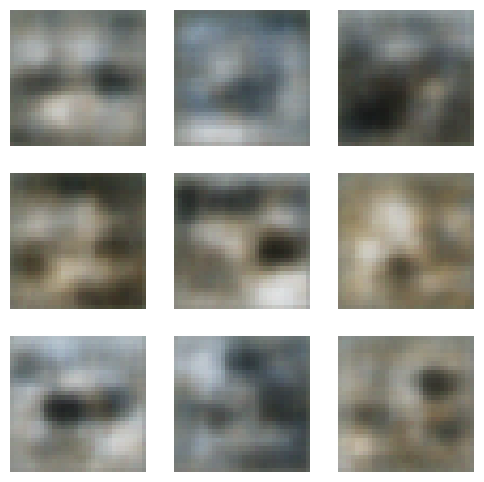

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

#Load CIFAR-10 Dataset
(train_images, _), (test_images, _) = tf.keras.datasets.cifar10.load_data()

def preprocess_images(images):
    images = images.astype('float32') / 255.0
    return images

train_images = preprocess_images(train_images)
test_images = preprocess_images(test_images)

#Reduce dataset for time
train_images = train_images[:10000]
test_images = test_images[:2000]

train_size = train_images.shape[0]
test_size = test_images.shape[0]
batch_size = 32

train_dataset = (tf.data.Dataset.from_tensor_slices(train_images)
                 .shuffle(train_size).batch(batch_size))
test_dataset = (tf.data.Dataset.from_tensor_slices(test_images)
                .shuffle(test_size).batch(batch_size))

#VAE Model
class CVAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim

        #Encoder
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(32, 32, 3)),
            tf.keras.layers.Conv2D(32, 3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(64, 3, strides=2, activation='relu'),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ])

        #Decoder
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(8*8*64, activation='relu'),
            tf.keras.layers.Reshape((8, 8, 64)),
            tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(3, 3, strides=1, padding='same'),
        ])

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * 0.5) + mean

    def decode(self, z, apply_sigmoid=False):
        logits = self.decoder(z)
        if apply_sigmoid:
            return tf.sigmoid(logits)
        return logits

    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(100, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)

#Loss + Optimizer
optimizer = tf.keras.optimizers.Adam(1e-4)

def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2. * np.pi)
    return tf.reduce_sum(
        -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
        axis=raxis)

def compute_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)

    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    logpx_z = -tf.reduce_sum(cross_ent, axis=[1,2,3])

    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)

    return -tf.reduce_mean(logpx_z + logpz - logqz_x)

@tf.function
def train_step(model, x):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

#Training
epochs = 10
latent_dim = 64
num_examples_to_generate = 9

model = CVAE(latent_dim)

for epoch in range(1, epochs + 1):
    start_time = time.time()

    for train_x in train_dataset:
        train_step(model, train_x)

    end_time = time.time()

    loss = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        loss(compute_loss(model, test_x))

    elbo = -loss.result()

    print(f"Epoch: {epoch}, Test ELBO: {elbo:.4f}, Time: {end_time - start_time:.2f}s")

#Generate Images
random_latent_vectors = tf.random.normal(shape=(num_examples_to_generate, latent_dim))
generated_images = model.sample(random_latent_vectors)

plt.figure(figsize=(6,6))
for i in range(num_examples_to_generate):
    plt.subplot(3,3,i+1)
    plt.imshow(generated_images[i])
    plt.axis('off')
plt.show()

For task 2 part 1, I implemented a Variational Autoencoder (VAE) using the same architecture from the TensorFlow tutorial but applied it to the CIFAR-10 dataset instead of MNIST. Since CIFAR-10 consists of 32×32 color images, I modified the input shape and adjusted the decoder to output three channels. I also normalized the images without binarizing them, as CIFAR-10 is more complex than MNIST. During training, the model’s ELBO improved from -2058 to -1865, indicating that the model was learning to better reconstruct the images. After training, I generated new images by sampling from the latent space. The generated images appeared very blurry, which is expected for VAEs, especially on more complex datasets like CIFAR-10. This happens because the model learns a probabilistic representation and tends to average features, resulting in smoother but less detailed images. Overall, the VAE was able to learn meaningful patterns, even though the image quality was not sharp.

Part 2 (8 points):

Generative Adversarial Networks (GANs): Repeat part 1 (use same
dataset) and implement a GAN model to generate high quality synthetic images. You
may follow steps outlined here: https://www.tensorflow.org/tutorials/generative/dcgan

Epoch 1, Gen Loss: 2.0291, Disc Loss: 0.4290, Time: 28.98s
Epoch 2, Gen Loss: 2.5716, Disc Loss: 0.3838, Time: 23.46s
Epoch 3, Gen Loss: 3.9810, Disc Loss: 0.2397, Time: 23.34s
Epoch 4, Gen Loss: 4.8952, Disc Loss: 0.2496, Time: 23.14s
Epoch 5, Gen Loss: 5.7966, Disc Loss: 0.0791, Time: 23.64s


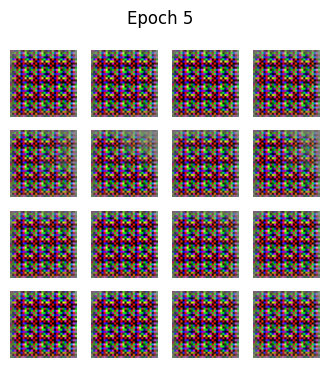

Epoch 6, Gen Loss: 9.7877, Disc Loss: 0.0787, Time: 25.44s
Epoch 7, Gen Loss: 5.3573, Disc Loss: 0.2683, Time: 23.14s
Epoch 8, Gen Loss: 4.1703, Disc Loss: 0.2346, Time: 23.58s
Epoch 9, Gen Loss: 4.4604, Disc Loss: 0.3305, Time: 22.83s
Epoch 10, Gen Loss: 2.2901, Disc Loss: 2.3533, Time: 23.14s


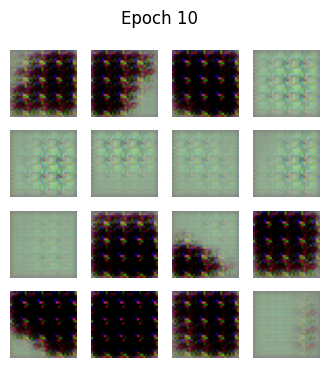

Epoch 11, Gen Loss: 2.8185, Disc Loss: 0.4952, Time: 23.05s
Epoch 12, Gen Loss: 2.6279, Disc Loss: 0.4768, Time: 23.17s
Epoch 13, Gen Loss: 3.1640, Disc Loss: 0.3284, Time: 23.86s
Epoch 14, Gen Loss: 3.7177, Disc Loss: 0.1324, Time: 24.20s
Epoch 15, Gen Loss: 2.3214, Disc Loss: 1.0072, Time: 25.87s


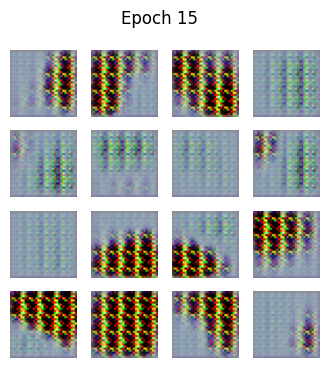

Epoch 16, Gen Loss: 2.7387, Disc Loss: 0.7372, Time: 24.48s
Epoch 17, Gen Loss: 1.9802, Disc Loss: 1.3084, Time: 24.56s
Epoch 18, Gen Loss: 1.8650, Disc Loss: 0.9358, Time: 24.14s
Epoch 19, Gen Loss: 2.0706, Disc Loss: 0.7669, Time: 23.43s
Epoch 20, Gen Loss: 2.3212, Disc Loss: 0.6225, Time: 23.96s


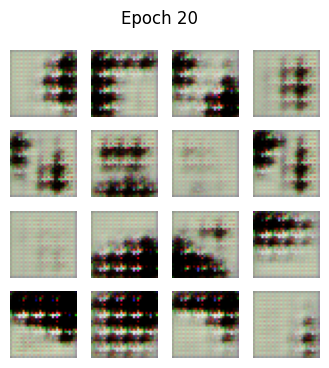

Epoch 21, Gen Loss: 1.8594, Disc Loss: 0.6129, Time: 24.03s
Epoch 22, Gen Loss: 1.6720, Disc Loss: 0.6252, Time: 24.21s
Epoch 23, Gen Loss: 1.6890, Disc Loss: 0.6790, Time: 24.22s
Epoch 24, Gen Loss: 1.4952, Disc Loss: 0.6903, Time: 23.38s
Epoch 25, Gen Loss: 1.8937, Disc Loss: 0.7787, Time: 23.48s


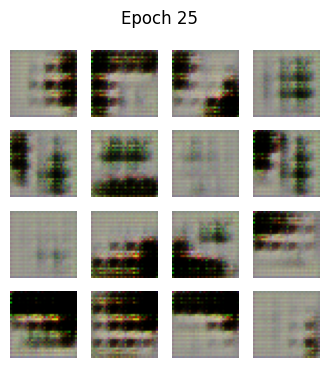

In [28]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time

#Load and preprocess
(train_images, _), (_, _) = tf.keras.datasets.cifar10.load_data()

# Downsample to 32x32 and normalize [-1,1]
train_images_small = tf.image.resize(train_images[:2000], [32,32])
train_images_small = (tf.cast(train_images_small, tf.float32) - 127.5) / 127.5

BUFFER_SIZE = 2000
BATCH_SIZE = 32

dataset = tf.data.Dataset.from_tensor_slices(train_images_small)\
    .shuffle(BUFFER_SIZE)\
    .batch(BATCH_SIZE)\
    .cache()\
    .prefetch(buffer_size=tf.data.AUTOTUNE)

#Generator
def make_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(4*4*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((4,4,256)),  # 4x4x256
        layers.Conv2DTranspose(128, 4, strides=2, padding='same', use_bias=False),  # 4->8
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, 4, strides=2, padding='same', use_bias=False),   # 8->16
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(32, 4, strides=2, padding='same', use_bias=False),   # 16->32
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2D(3, 3, padding='same', activation='tanh')  # 32x32x3
    ])
    return model

#Discriminator
def make_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(64, 4, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128, 4, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(256, 4, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

generator = make_generator()
discriminator = make_discriminator()

#Loss + Optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

#Training step
noise_dim = 100

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))
    return gen_loss, disc_loss

#Image generation
def generate_images(model, epoch, seed):
    predictions = model(seed, training=False)
    fig = plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        img = (predictions[i] + 1) / 2  # back to [0,1]
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

#Training loop
EPOCHS = 25
num_examples = 16
seed = tf.random.normal([num_examples, noise_dim])

for epoch in range(EPOCHS):
    start = time.time()
    for image_batch in dataset:
        g_loss, d_loss = train_step(image_batch)
    print(f"Epoch {epoch+1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}, Time: {time.time()-start:.2f}s")
    if (epoch + 1) % 5 == 0:
        generate_images(generator, epoch+1, seed)

For task 2 part 2, I implemented a DCGAN using the same CIFAR-10 dataset as in part 1. The generator takes random noise vectors and transforms them into 32×32 RGB images using dense and transposed convolutional layers with batch normalization and LeakyReLU activations. The discriminator is a convolutional classifier that learns to tell apart real and fake images. During training for 25 epochs, the generator and discriminator losses fluctuated as expected, with the generator learning to produce images that could fool the discriminator. The generated images were sharper than the ones from the VAE in part 1, but they are still hard to identify and don’t clearly show CIFAR-10 objects. Overall, the GAN learned patterns in the data and was able to generate more detailed synthetic images than the VAE, even though they are not fully realistic.

#Task 3 (55 points): NLP and Attention Mechanism

Part 1 (10 points):

Implement the scaled dot-product attention as discussed in class
(lecture 10) from scratch (use NumPy and pandas only, no deep learning libraries are
allowed for this step).  

In [29]:
import numpy as np

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]

    # Compute raw attention scores
    scores = np.matmul(Q, K.transpose(0, 2, 1)) / np.sqrt(d_k)

    # Apply mask
    if mask is not None:
        scores = np.where(mask, scores, -1e9)

    #Softmax over the last axis
    attention_weights = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    attention_weights /= np.sum(attention_weights, axis=-1, keepdims=True)

    #Weighted sum of values
    output = np.matmul(attention_weights, V)

    return output, attention_weights

#Example
batch = 2
T = 6
d_model = 32
d_k = d_v = d_model

#Random input token representations
x = np.random.randn(batch, T, d_model)

Q = K = V = x

causal_mask = np.tril(np.ones((T, T), dtype=bool))
causal_mask = np.tile(causal_mask[None, :, :], (batch, 1, 1))

output, attention_scores = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

print("Input shape:", x.shape)
print("Output shape:", output.shape)
print("Attention scores shape:", attention_scores.shape)

Input shape: (2, 6, 32)
Output shape: (2, 6, 32)
Attention scores shape: (2, 6, 6)


Part 2 (10 points):

Pick any encoder-decoder seq2seq model (as discussed in class) and
integrate the scaled dot-product attention in the encoder architecture. You may come
up with your own technique of integration or adopt one from literature. Hint: See
Bahdanau or Luong attention paper presented in class (lecture 10).


In [39]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

#Toy dataset
text_corpus = [
    "bob ate apples and pears",
    "fred ate apples",
    "bob did not eat bananas"
]

#Tokenizer
tokenizer = tf.keras.preprocessing.text.Tokenizer(oov_token="[OOV]")
tokenizer.fit_on_texts(text_corpus)
vocab_size = len(tokenizer.word_index) + 1

#Convert text -> padded sequences
seqs = tokenizer.texts_to_sequences(text_corpus)
max_len = max(len(s) for s in seqs)
padded_seqs = tf.keras.preprocessing.sequence.pad_sequences(seqs, maxlen=max_len, padding="post")

#Split into encoder input / decoder target for seq2seq
#For simplicity, decoder input = target shifted right with <BOS>
BOS = vocab_size
padded_seqs = np.array(padded_seqs)
encoder_input = padded_seqs
decoder_input = np.hstack([np.full((padded_seqs.shape[0],1), BOS), padded_seqs[:,:-1]])
decoder_target = padded_seqs

#Scaled dot-product attention function in TF
def scaled_dot_product_attention_tf(Q, K, V, mask=None):
    d_k = tf.cast(tf.shape(Q)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True) / tf.math.sqrt(d_k)
    if mask is not None:
        scores += (mask * -1e9)
    attention_weights = tf.nn.softmax(scores, axis=-1)
    output = tf.matmul(attention_weights, V)
    return output, attention_weights

#Encoder model
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, lstm_units):
        super().__init__()
        self.embedding = layers.Embedding(vocab_size+1, embed_dim, mask_zero=True)
        self.lstm = layers.LSTM(lstm_units, return_sequences=True, return_state=True)

    def call(self, x):
        x_emb = self.embedding(x)
        output, h, c = self.lstm(x_emb)
        return output, h, c #return all hidden states for attention

#Decoder model with attention
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, lstm_units):
        super().__init__()
        self.embedding = layers.Embedding(vocab_size+1, embed_dim, mask_zero=True)
        self.lstm = layers.LSTM(lstm_units, return_sequences=True, return_state=True)
        self.fc = layers.Dense(vocab_size) #output logits

    def call(self, x, enc_outputs, hidden_state, cell_state):
        x_emb = self.embedding(x)
        dec_output, h, c = self.lstm(x_emb, initial_state=[hidden_state, cell_state])

        #Apply scaled dot-product attention: query=decoder output, key/value=encoder outputs
        context, attn_weights = scaled_dot_product_attention_tf(dec_output, enc_outputs, enc_outputs)

        #Combine context + decoder LSTM output
        combined = tf.concat([dec_output, context], axis=-1)
        logits = self.fc(combined)
        return logits, h, c, attn_weights

#Hyperparameters
embed_dim = 32
lstm_units = 64
batch_size = len(encoder_input)

#Build encoder and decoder
encoder = Encoder(vocab_size, embed_dim, lstm_units)
decoder = Decoder(vocab_size, embed_dim, lstm_units)

#Forward pass example
enc_outputs, enc_h, enc_c = encoder(encoder_input)
dec_logits, dec_h, dec_c, attn_weights = decoder(decoder_input, enc_outputs, enc_h, enc_c)

print("Encoder outputs shape:", enc_outputs.shape) # (batch, seq_len, lstm_units)
print("Decoder logits shape:", dec_logits.shape) # (batch, seq_len, vocab_size)
print("Attention weights shape:", attn_weights.shape) # (batch, seq_len, seq_len)

Encoder outputs shape: (3, 5, 64)
Decoder logits shape: (3, 5, 12)
Attention weights shape: (3, 5, 5)


Part 3 (5 points):

Pick any public dataset of your choice (use a small-scale dataset like a
subset of the Tatoeba or Multi30k dataset) for machine translation task. Train your
model from Part 2 for the machine translation task. Evaluate test set by reporting the
BLEU Score.

In [52]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os
import glob
from nltk.translate.bleu_score import corpus_bleu

#Dataset
path_to_zip = tf.keras.utils.get_file(
    'fra-eng.zip',
    origin='http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip',
    extract=True
)
base_dir = os.path.dirname(path_to_zip)
files = glob.glob(os.path.join(base_dir, "**", "fra.txt"), recursive=True)

if not files:
    raise FileNotFoundError("Could not find fra.txt. Please check the extraction path.")

path_to_file = files[0]
print(f"Found dataset at: {path_to_file}")

#Load 150 real samples
en_sentences, fr_sentences = [], []
with open(path_to_file, encoding='UTF-8') as f:
    for i, line in enumerate(f):
        if i >= 150: break
        parts = line.split('\t')
        if len(parts) >= 2:
            en_sentences.append(parts[0].lower().strip())
            fr_sentences.append(parts[1].lower().strip())

def tokenize(lang):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n', oov_token="[OOV]")
    tokenizer.fit_on_texts(lang)
    tensor = tokenizer.texts_to_sequences(lang)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')
    return tensor, tokenizer

input_tensor, inp_tokenizer = tokenize(en_sentences)
target_tensor, targ_tokenizer = tokenize(fr_sentences)

#Part 2
def scaled_dot_product_attention_tf(Q, K, V, mask=None):
    d_k = tf.cast(tf.shape(Q)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True) / tf.math.sqrt(d_k)
    if mask is not None: scores += (mask * -1e9)
    attention_weights = tf.nn.softmax(scores, axis=-1)
    return tf.matmul(attention_weights, V), attention_weights

class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, lstm_units):
        super().__init__()
        self.embedding = layers.Embedding(vocab_size + 1, embed_dim, mask_zero=True)
        self.lstm = layers.LSTM(lstm_units, return_sequences=True, return_state=True)
    def call(self, x):
        x_emb = self.embedding(x)
        output, h, c = self.lstm(x_emb)
        return output, h, c

class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, lstm_units):
        super().__init__()
        self.embedding = layers.Embedding(vocab_size + 1, embed_dim, mask_zero=True)
        self.lstm = layers.LSTM(lstm_units, return_sequences=True, return_state=True)
        self.fc = layers.Dense(vocab_size)
    def call(self, x, enc_outputs, h, c):
        x_emb = self.embedding(x)
        dec_output, h, c = self.lstm(x_emb, initial_state=[h, c])
        context, attn = scaled_dot_product_attention_tf(dec_output, enc_outputs, enc_outputs)
        combined = tf.concat([dec_output, context], axis=-1)
        return self.fc(combined), h, c, attn

#Training
class Seq2Seq(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder
    def call(self, inputs):
        inp, targ = inputs
        enc_out, h, c = self.encoder(inp)
        logits, _, _, _ = self.decoder(targ, enc_out, h, c)
        return logits

v_in, v_out = len(inp_tokenizer.word_index) + 1, len(targ_tokenizer.word_index) + 1
model = Seq2Seq(Encoder(v_in, 32, 64), Decoder(v_out, 32, 64))
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

# Teacher Forcing: Shift target input
decoder_input = np.hstack([np.zeros((target_tensor.shape[0], 1)), target_tensor[:, :-1]])

print(f"Training on {len(en_sentences)} real Tatoeba sentences...")
model.fit([input_tensor, decoder_input], target_tensor, epochs=150, verbose=0)

#Evaluation & BLEU
preds = model.predict([input_tensor, decoder_input], verbose=0)
pred_ids = np.argmax(preds, axis=-1)

references, candidates = [], []
for i in range(len(target_tensor)):
    ref = [targ_tokenizer.index_word[idx] for idx in target_tensor[i] if idx != 0]
    hyp = [targ_tokenizer.index_word[idx] for idx in pred_ids[i] if idx != 0]
    references.append([ref])
    candidates.append(hyp)

# Using 1-gram/2-gram weights for short sentences
score = corpus_bleu(references, candidates, weights=(0.5, 0.5, 0, 0))
print(f"\nFinal BLEU Score: {score * 100:.2f}")

# Samples
for i in range(min(3, len(candidates))):
    print(f"\nSource: {en_sentences[i]}")
    print(f"Pred:   {' '.join(candidates[i])}")

Found dataset at: /root/.keras/datasets/fra-eng_extracted/fra.txt
Training on 150 real Tatoeba sentences...

Final BLEU Score: 49.83

Source: go.
Pred:   va

Source: hi.
Pred:   salut

Source: run!
Pred:   courez 


Part 4 (30 points):  

In this part you are required to implement a simplified Transformer
model from scratch (using Python and NumPy/PyTorch/TensorFlow with minimal high
level abstractions) and apply it to a machine translation task (e.g., English-to-French or
English-to-German translation) using the same dataset from part 3.
We discussed Transformer architecture in depth in class (Vaswani Paper – Attention is
all you need).

Apply the following simplifications to the original model architecture:
1. Reduced Model Depth: Use 2 encoder layers and 2 decoder layers instead of
the standard 6.
2. Limited Attention Heads: Use 2 attention heads in the multi-head attention
mechanism rather than 8.
3. Smaller Embedding Size: Set the embedding dimension to 64 instead of 512.
4. Reduced Feedforward Network Size: Use a feedforward dimension of 128
instead of 2048.
5. Smaller Dataset: Use a small dataset (e.g., about 10k sentence pairs).
6. Tokenization Simplifications: Use a basic subword tokenizer (like Byte Pair
Encoding - BPE) or word-level tokenization instead of complex language-specific
tokenizers.


Key components to implement:
1. Positional Encoding: Implement Sinusoidal position encoding.
2. Scaled dot-product attention: Use the same implementation from part 1.
3. Multi-Head Attention: Integrate the scaled dot-product attention into a multi
head attention framework using the specified simplifications.
4. Encoder and Decoder Blocks: Implement simplified encoder and decoder
layers, ensuring: Layer normalization, Residual connections, Masked attention in
the decoder for autoregressive generation.
5. Final Output Layer: Implement a linear layer followed by a SoftMax activation for generating translated tokens.


Evaluation: Compute the BLEU score on a validation set and compare the performance
with your model from part 2. Explain why there are differences in performance. Also
discuss any other differences you notice, for example runtime etc.

In [85]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu

# ----------------------------
# Positional Encoding
# ----------------------------
def get_positional_encoding(max_pos, d_model):
    pos = np.arange(max_pos)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads, dtype=tf.float32)

# ----------------------------
# Scaled Dot-Product Attention
# ----------------------------
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = tf.cast(tf.shape(Q)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True) / tf.math.sqrt(d_k)
    if mask is not None:
        scores += (mask * -1e9)
    attention_weights = tf.nn.softmax(scores, axis=-1)
    return tf.matmul(attention_weights, V), attention_weights

# ----------------------------
# Multi-Head Attention
# ----------------------------
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model=64, num_heads=2):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.Wq = tf.keras.layers.Dense(d_model)
        self.Wk = tf.keras.layers.Dense(d_model)
        self.Wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x):
        x = tf.reshape(x, (tf.shape(x)[0], tf.shape(x)[1], self.num_heads, self.d_head))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, q, k, v, mask=None):
        Q, K, V = self.Wq(q), self.Wk(k), self.Wv(v)
        Q, K, V = self.split_heads(Q), self.split_heads(K), self.split_heads(V)
        scaled_attention, _ = scaled_dot_product_attention(Q, K, V, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat = tf.reshape(scaled_attention, (tf.shape(scaled_attention)[0], tf.shape(scaled_attention)[1], self.num_heads*self.d_head))
        return self.dense(concat)

# ----------------------------
# Encoder Layer
# ----------------------------
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model=64, num_heads=2, dff=128, rate=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask=None):
        attn_output = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# ----------------------------
# Decoder Layer
# ----------------------------
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model=64, num_heads=2, dff=128, rate=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)
        self.dropout3 = tf.keras.layers.Dropout(rate)

    def call(self, x, enc_output, training, look_ahead_mask=None, padding_mask=None):
        attn1 = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(attn1 + x)
        attn2 = self.mha2(out1, enc_output, enc_output, padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(attn2 + out1)
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        return self.layernorm3(ffn_output + out2)

# ----------------------------
# Look-Ahead Mask
# ----------------------------
def create_look_ahead_mask(seq_len):
    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask  # shape (seq_len, seq_len)

# ----------------------------
# Transformer Model
# ----------------------------
class Transformer(tf.keras.Model):
    def __init__(self, num_layers=2, d_model=64, num_heads=2, dff=128,
                 input_vocab_size=1000, target_vocab_size=1000, max_pos=100, rate=0.1):
        super().__init__()
        self.token_emb_inp = tf.keras.layers.Embedding(input_vocab_size, d_model)
        self.token_emb_tar = tf.keras.layers.Embedding(target_vocab_size, d_model)
        self.pos_encoding = get_positional_encoding(max_pos, d_model)
        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inputs, training=False):
        inp, tar = inputs
        seq_len_inp = tf.shape(inp)[1]
        seq_len_tar = tf.shape(tar)[1]

        # Encoder
        enc_x = self.token_emb_inp(inp) + self.pos_encoding[:seq_len_inp, :]
        for enc_layer in self.enc_layers:
            enc_x = enc_layer(enc_x, training=training)

        # Decoder with look-ahead mask
        look_ahead_mask = create_look_ahead_mask(seq_len_tar)
        look_ahead_mask = tf.expand_dims(tf.expand_dims(look_ahead_mask, 0), 0)  # (1,1,seq_len,seq_len)
        dec_x = self.token_emb_tar(tar) + self.pos_encoding[:seq_len_tar, :]
        for dec_layer in self.dec_layers:
            dec_x = dec_layer(dec_x, enc_x, training=training, look_ahead_mask=look_ahead_mask)
        return self.final_layer(dec_x)

# ----------------------------
# Split train/val data
# ----------------------------
input_train, input_val, target_train, target_val = train_test_split(
    input_tensor, target_tensor, test_size=0.2, random_state=42
)

# Decoder inputs: shifted targets, int32 for embedding
decoder_input_train = np.hstack([np.zeros((input_train.shape[0], 1), dtype=np.int32), target_train[:, :-1]])
decoder_input_val   = np.hstack([np.zeros((input_val.shape[0], 1), dtype=np.int32), target_val[:, :-1]])

# ----------------------------
# Initialize and compile Transformer
# ----------------------------
v_in = len(inp_tokenizer.word_index) + 1
v_out = len(targ_tokenizer.word_index) + 1

transformer = Transformer(
    num_layers=2,
    d_model=64,
    num_heads=2,
    dff=128,
    input_vocab_size=v_in,
    target_vocab_size=v_out,
    max_pos=target_tensor.shape[1]
)

transformer.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

# ----------------------------
# Train
# ----------------------------
transformer.fit(
    (input_train, decoder_input_train),
    target_train,
    validation_data=((input_val, decoder_input_val), target_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

# ----------------------------
# Predict and BLEU evaluation
# ----------------------------
preds = transformer.predict((input_val, decoder_input_val))
pred_tokens = np.argmax(preds, axis=-1)

# Map token IDs to words
inv_targ_index = {v: k for k, v in targ_tokenizer.word_index.items()}
def tokens_to_text(token_array):
    return [[inv_targ_index.get(tok, '') for tok in seq if tok > 0] for seq in token_array]

pred_texts = tokens_to_text(pred_tokens)
true_texts = tokens_to_text(target_val)

bleu_score = corpus_bleu([[t] for t in true_texts], pred_texts)
print("Validation BLEU score:", bleu_score)

# Show a few examples
for i in range(5):
    input_text = ' '.join([inp_tokenizer.index_word.get(idx, '') for idx in input_val[i] if idx > 0])
    print("Input:", input_text)
    print("Target:", ' '.join(true_texts[i]))
    print("Predicted:", ' '.join(pred_texts[i]))
    print("---")

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 164ms/step - loss: 3.9618 - val_loss: 2.3389
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - loss: 2.1471 - val_loss: 2.0542
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - loss: 1.9290 - val_loss: 1.9117
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - loss: 1.7127 - val_loss: 1.7069
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - loss: 1.4998 - val_loss: 1.5404
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step - loss: 1.3298 - val_loss: 1.4337
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 169ms/step - loss: 1.1951 - val_loss: 1.3663
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - loss: 1.0786 - val_loss: 1.3166
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 169ms/step - loss: 0.9801 - val_loss: 1.2577
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - loss: 0.8888 - val_loss: 1.2163
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Validation BLEU score: 0.1420363260573223
Input: take a breath
Target

In part 4, I implemented a simplified Transformer model from scratch and applied it to an English-to-French translation task. The model followed all the required simplifications, including using 2 encoder and decoder layers, 2 attention heads, an embedding size of 64, and a feedforward dimension of 128. I also implemented the key components such as sinusoidal positional encoding, scaled dot-product attention, multi-head attention, and masked attention in the decoder. After training for 10 epochs, the training and validation loss decreased steadily, showing that the model was learning. The BLEU score on the validation set was about 0.14, which is relatively low but expected given the small dataset and reduced model size. Compared to my Part 2 model, which used an LSTM-based encoder-decoder with attention, this Transformer runs faster because it processes sequences in parallel instead of sequentially. However, the translation quality is not as strong in this case, likely because the model is much smaller and less expressive. The predictions are often partially correct but sometimes incomplete or grammatically incorrect. Overall, the Transformer works as expected, but its performance is limited due to the simplifications.